# 04 — ODEs and dynamical systems

Initial-value problem solvers from `numethods.ode`. Three flagship applications:

1. **Damped harmonic oscillator** – verifying solver accuracy on a system
    with a known closed form.
2. **Lotka–Volterra predator–prey** – periodic limit cycles in phase space.
3. **SIR epidemic** – sweeping the basic reproduction number $R_0$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7, 4.5), "figure.dpi": 110, "axes.grid": True})

from numethods import rk4, rk45_adaptive


## Damped harmonic oscillator: $\ddot{x} + 0.2\,\dot{x} + x = 0$

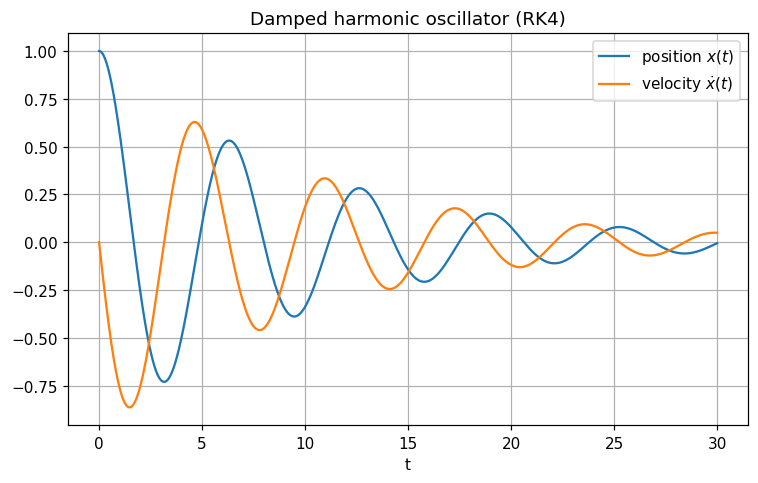

In [2]:
def damped(t, y):
    x, v = y
    return np.array([v, -0.2*v - x])

sol = rk4(damped, (0.0, 30.0), [1.0, 0.0], n_steps=2000)
fig, ax = plt.subplots()
ax.plot(sol.t, sol.y[:, 0], label='position $x(t)$')
ax.plot(sol.t, sol.y[:, 1], label='velocity $\\dot{x}(t)$')
ax.set_xlabel('t'); ax.set_title('Damped harmonic oscillator (RK4)')
ax.legend(); fig.tight_layout(); plt.show()


## Lotka–Volterra predator–prey

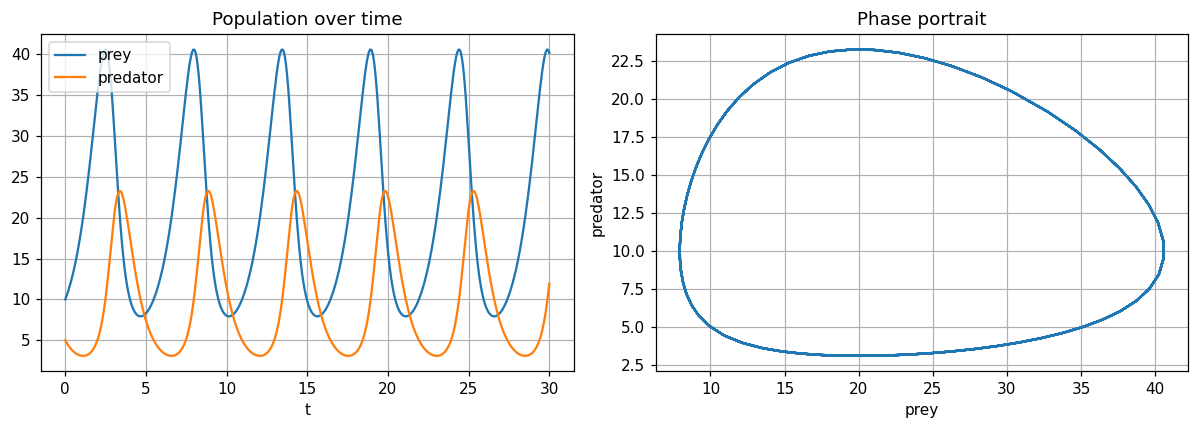

In [3]:
alpha, beta, gamma, delta = 1.0, 0.1, 1.5, 0.075
def lv(t, y):
    prey, pred = y
    return np.array([alpha*prey - beta*prey*pred,
                     delta*prey*pred - gamma*pred])

sol = rk45_adaptive(lv, (0.0, 30.0), [10.0, 5.0], rtol=1e-8)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(sol.t, sol.y[:, 0], label='prey')
axes[0].plot(sol.t, sol.y[:, 1], label='predator')
axes[0].set_xlabel('t'); axes[0].set_title('Population over time'); axes[0].legend()
axes[1].plot(sol.y[:, 0], sol.y[:, 1])
axes[1].set_xlabel('prey'); axes[1].set_ylabel('predator')
axes[1].set_title('Phase portrait')
fig.tight_layout(); plt.show()


## SIR epidemic: parameter sweep on $R_0 = \beta / \gamma$

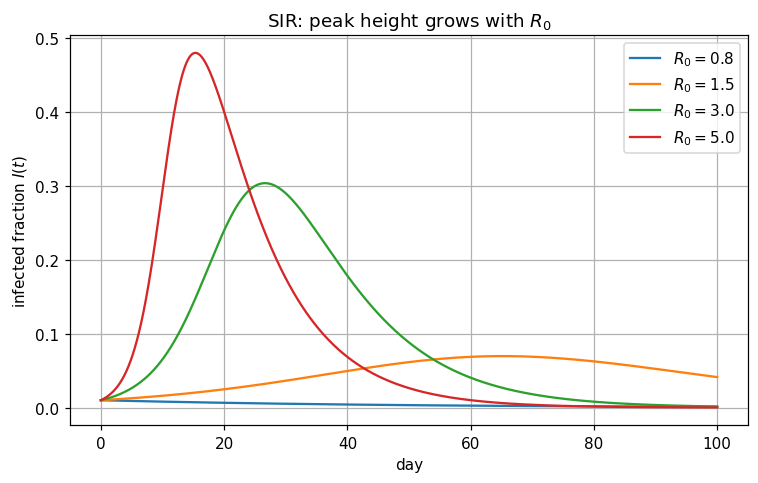

In [4]:
def sir(beta, gamma):
    def f(t, y):
        S, I, R = y
        return np.array([-beta*S*I, beta*S*I - gamma*I, gamma*I])
    return f

fig, ax = plt.subplots()
gamma = 0.1
for R0 in [0.8, 1.5, 3.0, 5.0]:
    beta = R0 * gamma
    sol = rk4(sir(beta, gamma), (0.0, 100.0), [0.99, 0.01, 0.0], n_steps=2000)
    ax.plot(sol.t, sol.y[:, 1], label=f'$R_0={R0}$')
ax.set_xlabel('day'); ax.set_ylabel('infected fraction $I(t)$')
ax.set_title('SIR: peak height grows with $R_0$'); ax.legend()
fig.tight_layout(); plt.show()


This notebook demonstrates `numethods.ode`.